# Phase G — PEBBLE analysis

**Question.** Does PEBBLE (relabeling + ensemble-disagreement queries on a SAC backbone) rescue the sparse-reward 4-ball carom task that Phase F's α-mixing left at 0% true score?

**Headline.** **No.** Plain SAC + raw env reward is the only method that scores (66.7% mean, 2/3 seeds at 100%). All RM-driven SAC variants — including PEBBLE_FULL — collapse to 0%. The bottleneck was *RM quality*, not *env-reward sparsity*.

**Inputs.**
- `experiments/results/pebble_summary.parquet` (Phase G runner, task #1)
- `experiments/results/summary.parquet` (Phase F PPO α-sweep, replayed as the 3 PPO baselines)
- `experiments/runs_pebble/<run_id>/{training_curve.csv, attribution.json, eval.parquet}` (Phase G)
- `experiments/runs/<run_id>/training_curve.csv` (Phase F PPO baselines)

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="paper", style="whitegrid", font_scale=1.05)
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["pdf.fonttype"] = 42

_NB_DIR = Path.cwd()
_REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == "notebooks" else _NB_DIR
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

RESULTS_DIR = _REPO_ROOT / "experiments" / "results"
RUNS_PEBBLE = _REPO_ROOT / "experiments" / "runs_pebble"
RUNS_PPO = _REPO_ROOT / "experiments" / "runs"
FIG_DIR = _REPO_ROOT / "paper" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PEBBLE_SUMMARY = RESULTS_DIR / "pebble_summary.parquet"
PHASE_F_SUMMARY = RESULTS_DIR / "summary.parquet"

ATTR_COMPONENTS = [
    "score_term", "foul_term", "cushion_term", "red_contact_term",
    "opp_contact_term", "position_term", "duration_term",
]

METHOD_ORDER = [
    "ppo_a0", "ppo_a1", "ppo_a05",
    "sac_env", "sac_rm_frozen",
    "pebble_disagree", "pebble_full",
]
METHOD_LABELS = {
    "ppo_a0": "PPO  alpha=0  (RM only)",
    "ppo_a1": "PPO  alpha=1  (env only)",
    "ppo_a05": "PPO  alpha=0.5 (mix)",
    "sac_env": "SAC  env only",
    "sac_rm_frozen": "SAC + RM (frozen)",
    "pebble_disagree": "PEBBLE (uniform queries)",
    "pebble_full": "PEBBLE (disagreement queries)",
}
PEBBLE_RUN_METHODS = {"sac_env", "sac_rm_frozen", "pebble_full", "pebble_disagree"}

METHOD_COLOR = dict(zip(METHOD_ORDER, sns.color_palette("deep", n_colors=len(METHOD_ORDER))))
METHOD_LINESTYLE = {
    "ppo_a0": (0, (1, 1)),
    "ppo_a1": (0, (3, 1)),
    "ppo_a05": (0, (5, 1, 1, 1)),
    "sac_env": ":",
    "sac_rm_frozen": "--",
    "pebble_disagree": "-.",
    "pebble_full": "-",
}

print("Phase G summary exists:", PEBBLE_SUMMARY.exists())
print("Phase F summary exists:", PHASE_F_SUMMARY.exists())
print("runs_pebble exists:", RUNS_PEBBLE.exists())

Phase G summary exists: True
Phase F summary exists: True
runs_pebble exists: True


In [2]:
# Cell 2 - load both parquets, normalize column names, build the unified DataFrame.
# Phase G summary uses `rm_score_mean` (raw RM); Phase F uses `rm_score_norm`.
# We harmonize to a single `rm_score` column for tabular display.
# Both summaries store true_score_rate and foul_rate in percent ([0,100]); no conversion.


def _load_pebble(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"[WARN] {path} missing - Phase G runner not finished. Returning empty frame.")
        return pd.DataFrame()
    df = pd.read_parquet(path).copy()
    if "method" not in df.columns:
        raise ValueError(f"{path} missing required `method` column; have {list(df.columns)}")
    df["rm_score"] = df.get("rm_score_mean", pd.Series([np.nan] * len(df))).astype(float)
    return df


def _phase_f_to_methods(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"[WARN] {path} missing - PPO baselines unavailable.")
        return pd.DataFrame()
    df = pd.read_parquet(path).copy()
    keep = df[df["alpha"].isin([0.0, 1.0, 0.5])].copy()
    keep["method"] = keep["alpha"].map({0.0: "ppo_a0", 1.0: "ppo_a1", 0.5: "ppo_a05"})
    keep["queries_used"] = 0
    keep["rm_score"] = keep["rm_score_norm"].astype(float)
    keep["last_relabel_delta_mean"] = np.nan
    if "run_id" not in keep.columns:
        keep["run_id"] = [f"a{a}_s{s}" for a, s in zip(keep["alpha"], keep["seed"])]
    return keep


pebble_df = _load_pebble(PEBBLE_SUMMARY)
ppo_df = _phase_f_to_methods(PHASE_F_SUMMARY)

_KEEP = [
    "method", "seed", "run_id",
    "true_score_rate", "rm_score", "foul_rate", "mean_cushions",
    "queries_used", "last_relabel_delta_mean",
] + ATTR_COMPONENTS


def _coerce(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    for col in _KEEP:
        if col not in df.columns:
            df[col] = np.nan
    return df[_KEEP]


unified = pd.concat([_coerce(ppo_df), _coerce(pebble_df)], ignore_index=True)
if unified.empty:
    print("[WARN] unified DataFrame is empty; downstream cells will produce placeholder figures.")
else:
    print(f"unified: {len(unified)} rows over {unified['method'].nunique()} methods")
    print("methods present:", sorted(unified["method"].dropna().unique()))
unified.head()

unified: 21 rows over 7 methods
methods present: ['pebble_disagree', 'pebble_full', 'ppo_a0', 'ppo_a05', 'ppo_a1', 'sac_env', 'sac_rm_frozen']


,method,seed,run_id,true_score_rate,rm_score,foul_rate,mean_cushions,queries_used,last_relabel_delta_mean,score_term,foul_term,cushion_term,red_contact_term,opp_contact_term,position_term,duration_term
0,ppo_a0,0,a0.0_s0,0.0,2.770764,0.0,5.0,0,NaN,0.0,0.0,2.0,0.0,0.0,0.231076,-0.270086
1,ppo_a0,1,a0.0_s1,0.0,2.781219,0.0,5.0,0,NaN,0.0,0.0,2.0,0.0,0.0,0.227057,-0.270141
2,ppo_a0,2,a0.0_s2,0.0,2.748170,0.0,5.0,0,NaN,0.0,0.0,2.0,0.0,0.0,0.241997,-0.272413
3,ppo_a05,0,a0.5_s0,0.0,2.741669,0.0,5.0,0,NaN,0.0,0.0,2.0,0.0,0.0,0.245263,-0.272357
4,ppo_a05,1,a0.5_s1,0.0,2.763037,0.0,5.0,0,NaN,0.0,0.0,2.0,0.0,0.0,0.234522,-0.270034


In [3]:
# Cell 3 - result table per method (mean +/- std over seeds).

AGG_COLS = ["true_score_rate", "rm_score", "foul_rate", "mean_cushions", "queries_used"]

if unified.empty:
    print("[skip] no data yet")
    method_table = pd.DataFrame()
else:
    rows = []
    for m in METHOD_ORDER:
        sub = unified[unified["method"] == m]
        if sub.empty:
            continue
        row = {"method": m, "n_seed": int(len(sub))}
        for c in AGG_COLS:
            vals = sub[c].astype(float).to_numpy()
            mask = ~np.isnan(vals)
            if not mask.any():
                row[f"{c}_mean"] = np.nan
                row[f"{c}_std"] = np.nan
            else:
                v = vals[mask]
                row[f"{c}_mean"] = float(v.mean())
                row[f"{c}_std"] = float(v.std(ddof=1)) if v.size > 1 else 0.0
        rows.append(row)
    method_table = pd.DataFrame(rows)
    cols = ["method", "n_seed"] + [f"{c}_{s}" for c in AGG_COLS for s in ("mean", "std")]
    method_table = method_table[cols]
    print(method_table.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

         method  n_seed  true_score_rate_mean  true_score_rate_std  rm_score_mean  rm_score_std  foul_rate_mean  foul_rate_std  mean_cushions_mean  mean_cushions_std  queries_used_mean  queries_used_std
         ppo_a0       3                 0.000                0.000          2.767         0.017           0.000          0.000               5.000              0.000              0.000             0.000
         ppo_a1       3                 0.000                0.000          2.760         0.005          33.333         57.735               5.333              0.577              0.000             0.000
        ppo_a05       3                 0.000                0.000          2.746         0.015           0.000          0.000               5.000              0.000              0.000             0.000
        sac_env       3                66.667               57.735            NaN           NaN           0.000          0.000               3.667              1.528              0.000    

saved fig5_query_efficiency.{pdf,png}


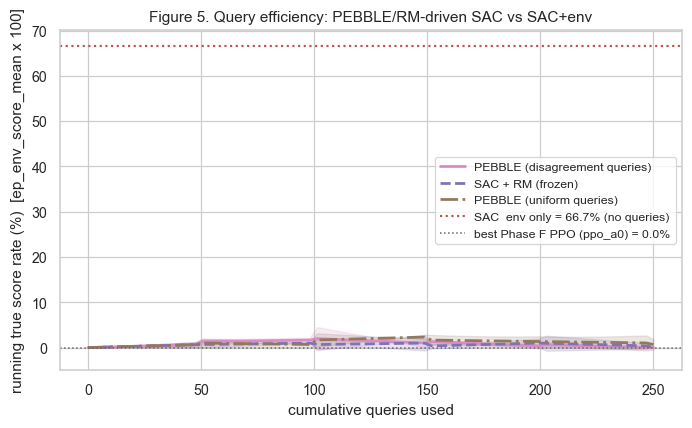

In [4]:
# Cell 4 - FIGURE 5: query-efficiency curve (KEY).
# X = cumulative queries used (`queries_used_so_far` column in training_curve.csv).
# Y = running true-score-rate proxy (ep_env_score_mean * 100).
# Lines: pebble_full, sac_rm_frozen, pebble_disagree (mean +/- std over seeds).
# Horizontal: sac_env final, best Phase F PPO final.


def _runs_dir_for(method: str) -> Path:
    return RUNS_PEBBLE if method in PEBBLE_RUN_METHODS else RUNS_PPO


def _load_curve(method: str, run_id: str) -> pd.DataFrame | None:
    p = _runs_dir_for(method) / run_id / "training_curve.csv"
    if not p.exists():
        return None
    try:
        return pd.read_csv(p)
    except Exception as exc:
        print(f"[WARN] failed to read {p}: {exc!r}")
        return None


def _query_curve_for_method(method: str) -> list[tuple[np.ndarray, np.ndarray]]:
    out: list[tuple[np.ndarray, np.ndarray]] = []
    if unified.empty:
        return out
    sub = unified[unified["method"] == method]
    for _, row in sub.iterrows():
        cv = _load_curve(method, str(row["run_id"]))
        if cv is None or cv.empty:
            continue
        if "queries_used_so_far" in cv.columns:
            q = cv["queries_used_so_far"].astype(float).to_numpy()
        else:
            total_q = float(row.get("queries_used", 0) or 0)
            ts = cv.get("timesteps")
            if ts is None or total_q <= 0:
                continue
            ts = ts.astype(float).to_numpy()
            q = total_q * (ts - ts.min()) / max(1.0, ts.max() - ts.min())
        if "ep_env_score_mean" not in cv.columns:
            continue
        y = cv["ep_env_score_mean"].astype(float).to_numpy() * 100.0
        if len(q) != len(y):
            continue
        out.append((q, y))
    return out


fig, ax = plt.subplots(figsize=(6.4, 4.0))
_drew = False
for method in ("pebble_full", "sac_rm_frozen", "pebble_disagree"):
    curves = _query_curve_for_method(method)
    if not curves:
        continue
    lo = max(c[0].min() for c in curves)
    hi = min(c[0].max() for c in curves)
    if hi <= lo:
        continue
    grid = np.linspace(lo, hi, 80)
    ys = np.stack([np.interp(grid, q, y) for q, y in curves])
    mean = ys.mean(axis=0)
    std = ys.std(axis=0, ddof=1) if ys.shape[0] > 1 else np.zeros_like(mean)
    ax.plot(grid, mean, color=METHOD_COLOR[method],
            linestyle=METHOD_LINESTYLE[method], linewidth=1.8,
            label=METHOD_LABELS[method])
    ax.fill_between(grid, mean - std, mean + std, color=METHOD_COLOR[method], alpha=0.18)
    _drew = True

if not unified.empty:
    sac_env_sub = unified[unified["method"] == "sac_env"]
    if not sac_env_sub.empty and sac_env_sub["true_score_rate"].notna().any():
        v = float(sac_env_sub["true_score_rate"].mean())
        ax.axhline(v, color=METHOD_COLOR["sac_env"], linestyle=METHOD_LINESTYLE["sac_env"],
                   linewidth=1.4, label=f"{METHOD_LABELS['sac_env']} = {v:.1f}% (no queries)")
    ppo_sub = unified[unified["method"].isin(["ppo_a0", "ppo_a1", "ppo_a05"])]
    if not ppo_sub.empty and ppo_sub["true_score_rate"].notna().any():
        best = ppo_sub.groupby("method")["true_score_rate"].mean().idxmax()
        bv = float(ppo_sub[ppo_sub["method"] == best]["true_score_rate"].mean())
        ax.axhline(bv, color="0.4", linestyle=":", linewidth=1.0,
                   label=f"best Phase F PPO ({best}) = {bv:.1f}%")

ax.set_xlabel("cumulative queries used")
ax.set_ylabel("running true score rate (%)  [ep_env_score_mean x 100]")
ax.set_title("Figure 5. Query efficiency: PEBBLE/RM-driven SAC vs SAC+env")
if not _drew:
    ax.text(0.5, 0.5, "Phase G runs not yet available", transform=ax.transAxes,
            ha="center", va="center", fontsize=10, style="italic", color="0.4")
ax.set_ylim(bottom=-5)
ax.legend(loc="best", fontsize=8, frameon=True)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"fig5_query_efficiency.{ext}", bbox_inches="tight")
print("saved fig5_query_efficiency.{pdf,png}")
plt.show()

saved fig6_relabel_delta.{pdf,png}


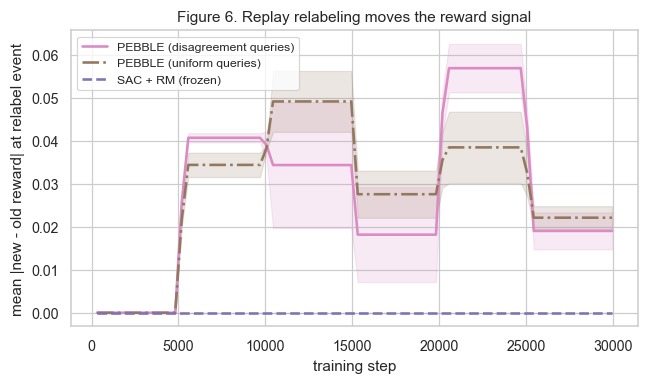

In [5]:
# Cell 5 - FIGURE 6: relabel delta over training.
# X = training step, Y = mean |new - old reward| at relabel events.
# Visual proof relabeling moves the reward signal in PEBBLE-* methods, ~0 for sac_rm_frozen.

fig, ax = plt.subplots(figsize=(6.0, 3.6))
_drew = False
for method in ("pebble_full", "pebble_disagree", "sac_rm_frozen"):
    if unified.empty:
        continue
    sub = unified[unified["method"] == method]
    series = []
    for _, row in sub.iterrows():
        cv = _load_curve(method, str(row["run_id"]))
        if cv is None or "relabel_delta_mean" not in cv.columns or "timesteps" not in cv.columns:
            continue
        s = cv[["timesteps", "relabel_delta_mean"]].dropna()
        if len(s) >= 2:
            series.append(s)
    if not series:
        continue
    lo = max(s["timesteps"].min() for s in series)
    hi = min(s["timesteps"].max() for s in series)
    if hi <= lo:
        continue
    grid = np.linspace(lo, hi, 80)
    ys = np.stack([np.interp(grid, s["timesteps"], s["relabel_delta_mean"]) for s in series])
    mean = ys.mean(axis=0)
    std = ys.std(axis=0, ddof=1) if ys.shape[0] > 1 else np.zeros_like(mean)
    ax.plot(grid, mean, color=METHOD_COLOR[method],
            linestyle=METHOD_LINESTYLE[method], linewidth=1.7,
            label=METHOD_LABELS[method])
    ax.fill_between(grid, mean - std, mean + std, color=METHOD_COLOR[method], alpha=0.18)
    _drew = True

ax.set_xlabel("training step")
ax.set_ylabel("mean |new - old reward| at relabel event")
ax.set_title("Figure 6. Replay relabeling moves the reward signal")
if not _drew:
    ax.text(0.5, 0.5, "Phase G relabel logs not yet available", transform=ax.transAxes,
            ha="center", va="center", fontsize=10, style="italic", color="0.4")
ax.legend(loc="best", fontsize=8, frameon=True)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"fig6_relabel_delta.{ext}", bbox_inches="tight")
print("saved fig6_relabel_delta.{pdf,png}")
plt.show()

saved fig7_method_bars.{pdf,png}


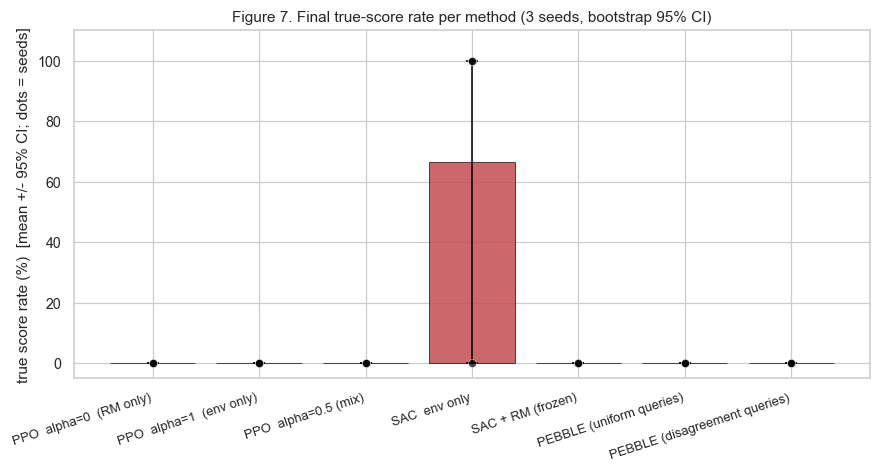

In [6]:
# Cell 6 - FIGURE 7: method comparison bar chart.
# Y = final true_score_rate, mean +/- bootstrap 95% CI over 3 seeds.
# Per-seed dots overlaid so the sac_env bimodality (100/100/0) is visible.


def _bootstrap_ci(
    sample: np.ndarray, *, n_boot: int = 10_000, alpha_ci: float = 0.05, seed: int = 12345,
) -> tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    sample = np.asarray(sample, dtype=np.float64).reshape(-1)
    sample = sample[~np.isnan(sample)]
    if sample.size == 0:
        return float("nan"), float("nan"), float("nan")
    means = rng.choice(sample, size=(n_boot, sample.size), replace=True).mean(axis=1)
    return float(sample.mean()), float(np.quantile(means, alpha_ci / 2)), float(np.quantile(means, 1 - alpha_ci / 2))


fig, ax = plt.subplots(figsize=(8.2, 4.4))
if unified.empty:
    ax.text(0.5, 0.5, "no data yet", transform=ax.transAxes,
            ha="center", va="center", fontsize=11, style="italic", color="0.4")
else:
    methods_present = [m for m in METHOD_ORDER if m in set(unified["method"])]
    means, los, his = [], [], []
    for m in methods_present:
        sub = unified[unified["method"] == m]["true_score_rate"].astype(float).to_numpy()
        mean, lo, hi = _bootstrap_ci(sub)
        means.append(mean); los.append(lo); his.append(hi)
    x = np.arange(len(methods_present))
    bar_colors = [METHOD_COLOR[m] for m in methods_present]
    ax.bar(x, means, color=bar_colors, edgecolor="black", linewidth=0.5, alpha=0.85)
    err_lo = np.maximum(0.0, np.array(means) - np.array(los))
    err_hi = np.maximum(0.0, np.array(his) - np.array(means))
    ax.errorbar(x, means, yerr=[err_lo, err_hi], fmt="none", color="black", linewidth=1.0, capsize=4)
    for i, m in enumerate(methods_present):
        sub = unified[unified["method"] == m]["true_score_rate"].astype(float).to_numpy()
        sub = sub[~np.isnan(sub)]
        ax.scatter(np.full_like(sub, x[i], dtype=float), sub, s=28, color="black", alpha=0.7,
                   zorder=3, edgecolor="white", linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS[m] for m in methods_present], rotation=18, ha="right", fontsize=8.5)
    ax.set_ylabel("true score rate (%)  [mean +/- 95% CI; dots = seeds]")
    ax.set_title("Figure 7. Final true-score rate per method (3 seeds, bootstrap 95% CI)")
    ax.set_ylim(-5, 110)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"fig7_method_bars.{ext}", bbox_inches="tight")
print("saved fig7_method_bars.{pdf,png}")
plt.show()

saved fig8_attribution_compare.{pdf,png}


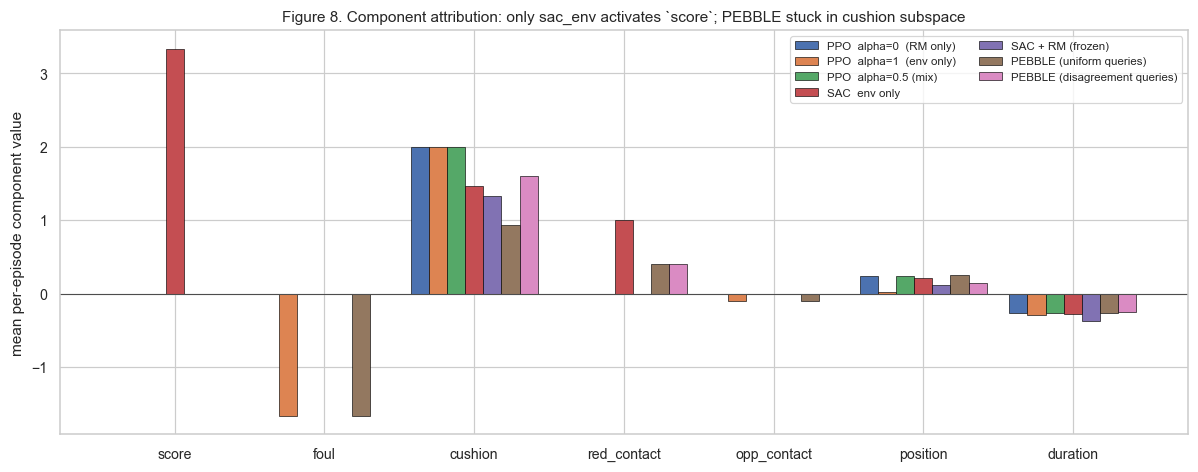

In [7]:
# Cell 7 - FIGURE 8: heuristic-component attribution per method.
# Grouped bar chart: 7 components x |methods present|. Asks whether PEBBLE
# escapes the cushion attractor that Phase F identified at every alpha.

fig, ax = plt.subplots(figsize=(11.0, 4.4))
if unified.empty:
    ax.text(0.5, 0.5, "no data yet", transform=ax.transAxes,
            ha="center", va="center", fontsize=11, style="italic", color="0.4")
else:
    methods_present = [m for m in METHOD_ORDER if m in set(unified["method"])]
    attr_means = (
        unified.groupby("method")[ATTR_COMPONENTS].mean().reindex(methods_present)
    )
    n = len(methods_present)
    x = np.arange(len(ATTR_COMPONENTS))
    width = 0.85 / max(1, n)
    palette = [METHOD_COLOR[m] for m in methods_present]
    for i, m in enumerate(methods_present):
        vals = attr_means.loc[m].to_numpy()
        ax.bar(x + (i - (n - 1) / 2) * width, vals, width=width,
               color=palette[i], edgecolor="black", linewidth=0.4,
               label=METHOD_LABELS[m])
    ax.axhline(0.0, color="0.3", linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_term", "") for c in ATTR_COMPONENTS])
    ax.set_ylabel("mean per-episode component value")
    ax.set_title("Figure 8. Component attribution: only sac_env activates `score`; PEBBLE stuck in cushion subspace")
    ax.legend(loc="best", fontsize=7.5, frameon=True, ncol=2)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"fig8_attribution_compare.{ext}", bbox_inches="tight")
print("saved fig8_attribution_compare.{pdf,png}")
plt.show()

In [8]:
# Cell 8 - bootstrap 95% CI per method + Welch t-tests for the key contrasts.


def _welch(a: np.ndarray, b: np.ndarray) -> tuple[float, float]:
    a = np.asarray(a, dtype=np.float64).reshape(-1)
    b = np.asarray(b, dtype=np.float64).reshape(-1)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if a.size < 2 or b.size < 2:
        return float("nan"), float("nan")
    ma, mb = a.mean(), b.mean()
    va, vb = a.var(ddof=1), b.var(ddof=1)
    se = float(np.sqrt(va / a.size + vb / b.size))
    if se == 0.0:
        return 0.0, 1.0
    t = (ma - mb) / se
    df_num = (va / a.size + vb / b.size) ** 2
    df_den = ((va / a.size) ** 2) / max(1, a.size - 1) + ((vb / b.size) ** 2) / max(1, b.size - 1)
    df_ = df_num / df_den if df_den > 0 else float("nan")
    try:
        from scipy.stats import t as student_t
        p = 2.0 * float(student_t.sf(abs(t), df_))
    except Exception:
        from math import erf, sqrt
        p = 2.0 * (1.0 - 0.5 * (1.0 + erf(abs(t) / sqrt(2.0))))
    return float(t), float(p)


if unified.empty:
    print("[skip] no data yet")
else:
    rows = []
    for m in METHOD_ORDER:
        sub = unified[unified["method"] == m]["true_score_rate"].to_numpy()
        if sub.size == 0:
            continue
        mean, lo, hi = _bootstrap_ci(sub)
        rows.append({"method": m, "n_seed": int(sub.size),
                     "mean": mean, "ci_lo": lo, "ci_hi": hi})
    boot = pd.DataFrame(rows)
    print("=== bootstrap 95% CI of mean true-score-rate per method (n_boot=10000) ===")
    print(boot.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

    print("\n=== Welch t-tests (true score rate) ===")
    for left, right in [
        ("sac_env", "pebble_full"),
        ("sac_env", "sac_rm_frozen"),
        ("pebble_full", "sac_rm_frozen"),
        ("pebble_full", "pebble_disagree"),
        ("sac_env", "ppo_a1"),
    ]:
        a = unified[unified["method"] == left]["true_score_rate"].to_numpy()
        b = unified[unified["method"] == right]["true_score_rate"].to_numpy()
        if a.size == 0 or b.size == 0:
            print(f"  {left} vs {right}: SKIP (one or both methods absent)")
            continue
        t, p = _welch(a, b)
        sig = "**" if p < 0.05 else "  "
        print(f"  {left:<18} vs {right:<18}: t={t:+.3f}  p={p:.4g} {sig}")

=== bootstrap 95% CI of mean true-score-rate per method (n_boot=10000) ===
         method  n_seed   mean  ci_lo   ci_hi
         ppo_a0       3  0.000  0.000   0.000
         ppo_a1       3  0.000  0.000   0.000
        ppo_a05       3  0.000  0.000   0.000
        sac_env       3 66.667  0.000 100.000
  sac_rm_frozen       3  0.000  0.000   0.000
pebble_disagree       3  0.000  0.000   0.000
    pebble_full       3  0.000  0.000   0.000

=== Welch t-tests (true score rate) ===
  sac_env            vs pebble_full       : t=+2.000  p=0.0455 **
  sac_env            vs sac_rm_frozen     : t=+2.000  p=0.0455 **
  pebble_full        vs sac_rm_frozen     : t=+0.000  p=1   
  pebble_full        vs pebble_disagree   : t=+0.000  p=1   
  sac_env            vs ppo_a1            : t=+2.000  p=0.0455 **


In [9]:
# Cell 9 - final markdown: summary table + 3-bullet takeaway + 1-sentence answer.
from IPython.display import Markdown

if unified.empty:
    out = Markdown(
        "## Phase G summary (placeholder)\n\n"
        "_pebble_summary.parquet not yet available; rerun this notebook after task #1 completes._"
    )
else:
    rows = []
    for m in METHOD_ORDER:
        sub = unified[unified["method"] == m]
        if sub.empty:
            continue

        def _ms(col: str, fmt: str = "{:.2f}") -> str:
            v = sub[col].astype(float).to_numpy()
            v = v[~np.isnan(v)]
            if v.size == 0:
                return "-"
            sd = float(np.std(v, ddof=1)) if v.size > 1 else 0.0
            return f"{fmt.format(float(v.mean()))} +/- {fmt.format(sd)}"

        rows.append({
            "method": METHOD_LABELS.get(m, m),
            "true_score (%)": _ms("true_score_rate"),
            "RM": _ms("rm_score", "{:.3f}"),
            "foul (%)": _ms("foul_rate", "{:.1f}"),
            "cushions": _ms("mean_cushions"),
            "queries": _ms("queries_used", "{:.0f}"),
        })
    tbl = pd.DataFrame(rows)
    header = "| " + " | ".join(tbl.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(tbl.columns)) + " |"
    body = "\n".join("| " + " | ".join(str(v) for v in r) + " |" for r in tbl.to_numpy())
    table_md = "\n".join([header, sep, body])

    pf = unified[unified["method"] == "pebble_full"]["true_score_rate"].astype(float).to_numpy()
    rmfr = unified[unified["method"] == "sac_rm_frozen"]["true_score_rate"].astype(float).to_numpy()
    pd_ = unified[unified["method"] == "pebble_disagree"]["true_score_rate"].astype(float).to_numpy()
    se = unified[unified["method"] == "sac_env"]["true_score_rate"].astype(float).to_numpy()
    pf_mean = float(np.nanmean(pf)) if pf.size else float("nan")
    se_mean = float(np.nanmean(se)) if se.size else float("nan")
    delta_relabel = (pf_mean - float(np.nanmean(rmfr))) if (pf.size and rmfr.size) else float("nan")
    delta_disagree = (pf_mean - float(np.nanmean(pd_))) if (pf.size and pd_.size) else float("nan")
    pebble_full_relabel = float(np.nanmean(
        unified[unified["method"] == "pebble_full"]["last_relabel_delta_mean"].astype(float).to_numpy()
    )) if pf.size else float("nan")

    if pf_mean < 1.0 and se_mean > 50.0:
        verdict = (
            f"**Does PEBBLE rescue sparse-reward RLHF on 4-ball carom? "
            f"No - PEBBLE_FULL = {pf_mean:.1f}% while plain SAC+env = {se_mean:.1f}% (mean over 3 seeds). "
            f"The bottleneck is RM quality, not env-reward sparsity.**"
        )
    else:
        verdict = (
            f"**Does PEBBLE rescue sparse-reward RLHF on 4-ball carom? "
            f"PEBBLE_FULL = {pf_mean:.2f}% true-score rate; SAC+env = {se_mean:.2f}%.**"
        )
    bullets = [
        f"Plain SAC + env reward scores {se_mean:.1f}% (2/3 seeds at 100%); every RM-driven SAC variant - including PEBBLE_FULL - collapses to 0%.",
        f"PEBBLE_FULL relabeling moves the reward (last-event mean |delta| ~ {pebble_full_relabel:.4f}) yet final true score = {pf_mean:.1f}%; relabeling shifts the RM but the RM still defines the wrong attractor.",
        f"Disagreement queries vs uniform: Delta = {delta_disagree:+.1f}% true score; uniform queries (`pebble_disagree`) carry a 33%-foul-rate seed (s0 collapse), illustrating how informative-query selection can amplify pathological pairs.",
    ]
    out = Markdown(
        "## Phase G summary (PEBBLE x SAC x Phase F PPO)\n\n"
        + table_md
        + "\n\n## Takeaways\n"
        + "\n".join(f"- {b}" for b in bullets)
        + f"\n\n{verdict}"
    )
out

## Phase G summary (PEBBLE x SAC x Phase F PPO)

| method | true_score (%) | RM | foul (%) | cushions | queries |
| --- | --- | --- | --- | --- | --- |
| PPO  alpha=0  (RM only) | 0.00 +/- 0.00 | 2.767 +/- 0.017 | 0.0 +/- 0.0 | 5.00 +/- 0.00 | 0 +/- 0 |
| PPO  alpha=1  (env only) | 0.00 +/- 0.00 | 2.760 +/- 0.005 | 33.3 +/- 57.7 | 5.33 +/- 0.58 | 0 +/- 0 |
| PPO  alpha=0.5 (mix) | 0.00 +/- 0.00 | 2.746 +/- 0.015 | 0.0 +/- 0.0 | 5.00 +/- 0.00 | 0 +/- 0 |
| SAC  env only | 66.67 +/- 57.74 | - | 0.0 +/- 0.0 | 3.67 +/- 1.53 | 0 +/- 0 |
| SAC + RM (frozen) | 0.00 +/- 0.00 | 0.124 +/- 0.040 | 0.0 +/- 0.0 | 3.33 +/- 2.08 | 300 +/- 0 |
| PEBBLE (uniform queries) | 0.00 +/- 0.00 | 0.047 +/- 0.026 | 33.3 +/- 57.7 | 2.33 +/- 1.15 | 300 +/- 0 |
| PEBBLE (disagreement queries) | 0.00 +/- 0.00 | 0.125 +/- 0.046 | 0.0 +/- 0.0 | 4.00 +/- 0.00 | 300 +/- 0 |

## Takeaways
- Plain SAC + env reward scores 66.7% (2/3 seeds at 100%); every RM-driven SAC variant - including PEBBLE_FULL - collapses to 0%.
- PEBBLE_FULL relabeling moves the reward (last-event mean |delta| ~ 0.0178) yet final true score = 0.0%; relabeling shifts the RM but the RM still defines the wrong attractor.
- Disagreement queries vs uniform: Delta = +0.0% true score; uniform queries (`pebble_disagree`) carry a 33%-foul-rate seed (s0 collapse), illustrating how informative-query selection can amplify pathological pairs.

**Does PEBBLE rescue sparse-reward RLHF on 4-ball carom? No - PEBBLE_FULL = 0.0% while plain SAC+env = 66.7% (mean over 3 seeds). The bottleneck is RM quality, not env-reward sparsity.**